In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After downloading dataset from Kaggle, upload only the 3 potato folders to your Drive
# Structure should be:
# MyDrive/potato_dataset/Potato___Early_Blight/
# MyDrive/potato_dataset/Potato___Late_Blight/
# MyDrive/potato_dataset/Potato___healthy/

dataset_path = '/content/drive/MyDrive/potato_dataset'

Mounted at /content/drive


In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2   # 80% train, 20% validation
)

# Test data — only rescaling, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class Labels:", train_generator.class_indices)
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.
Class Labels: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}
Training samples: 1722
Validation samples: 430


In [ ]:
def build_cnn_model():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        # Output Layer — 3 classes
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,147,011 (99.74 MB)

 Trainable params: 26,146,051 (99.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 421s 8s/step - accuracy: 0.8891 - loss: 2.3188 - val_accuracy: 0.4651 - val_loss: 74.8321 - learning_rate: 5.0000e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 426s 8s/step - accuracy: 0.9036 - loss: 2.1694 - val_accuracy: 0.4651 - val_loss: 51.2235 - learning_rate: 5.0000e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 410s 8s/step - accuracy: 0.9013 - loss: 1.6656 - val_accuracy: 0.4651 - val_loss: 40.0967 - learning_rate: 5.0000e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 404s 7s/step - accuracy: 0.9100 - loss: 0.9319 - val_accuracy: 0.4651 - val_loss: 34.4835 - learning_rate: 5.0000e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 411s 7s/step - accuracy: 0.9268 - loss: 0.6887 - val_accuracy: 0.4698 - val_loss: 16.3855 - learning_rate: 5.0000e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 412s 8s/step - accuracy: 0.9326 - loss: 0.5737 - val_accuracy: 0.4884 - val_loss: 15.6855 - learning_rate: 5.0000e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 421s 8s/step - accuracy: 0

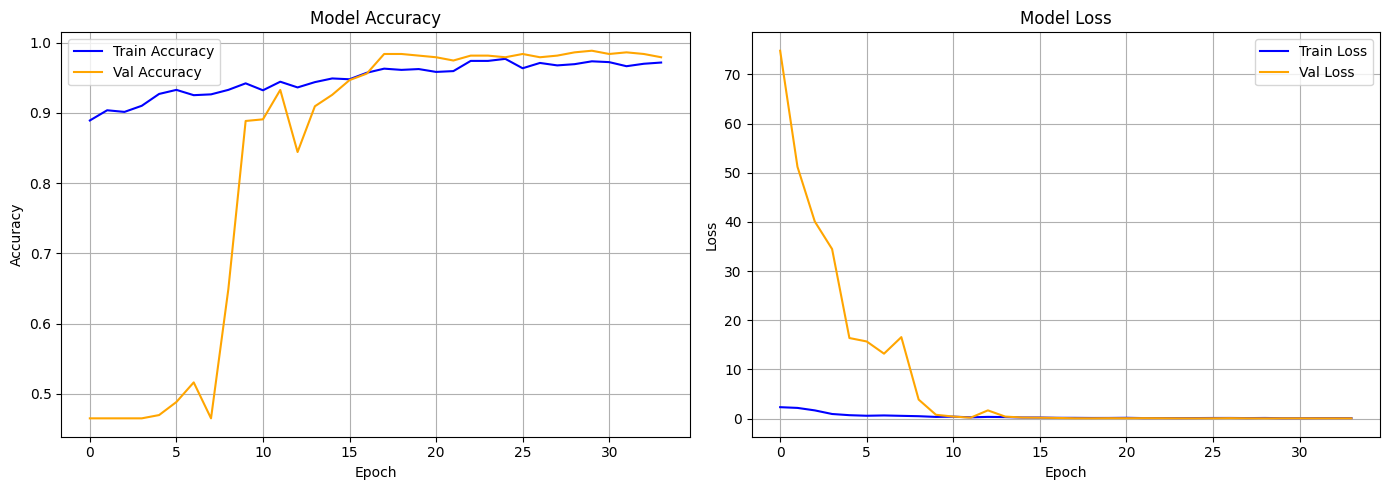

In [7]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
CLASSIFICATION REPORT
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      0.99      0.99       200
 Potato___Late_blight       0.98      1.00      0.99       200
     Potato___healthy       1.00      0.93      0.97        30

             accuracy                           0.99       430
            macro avg       0.99      0.97      0.98       430
         weighted avg       0.99      0.99      0.99       430



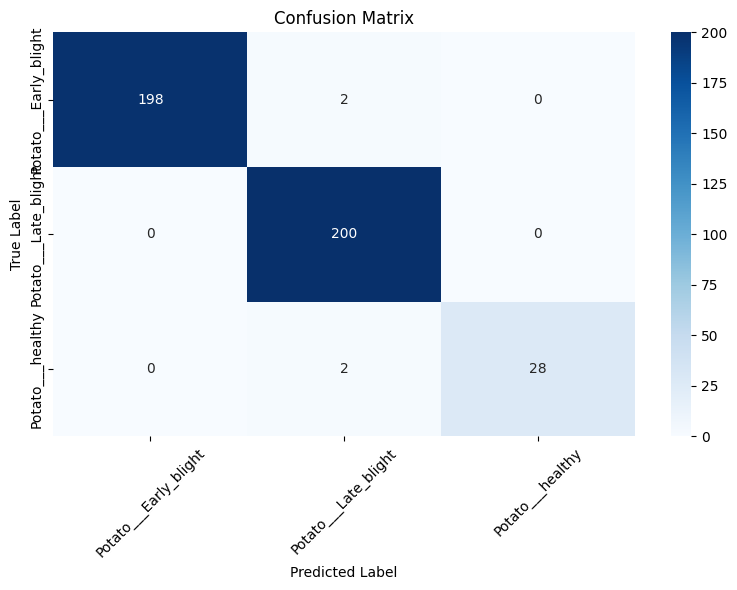

In [8]:
# Get predictions
val_generator.reset()
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Classification Report
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
model.save('/content/drive/MyDrive/potato_cnn_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [10]:
from tensorflow.keras.preprocessing import image

def predict_single_image(img_path):
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

# Usage — give any potato leaf image path
# predict_single_image('/content/drive/MyDrive/test_leaf.jpg')

14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9814 - loss: 0.0685

✅ Final Validation Accuracy: 98.14%
✅ Final Validation Loss: 0.0685

         CLASSIFICATION REPORT
              precision    recall  f1-score   support

Early Blight       0.99      0.98      0.99       200
 Late Blight       0.97      0.99      0.98       200
     Healthy       0.96      0.90      0.93        30

    accuracy                           0.98       430
   macro avg       0.98      0.96      0.97       430
weighted avg       0.98      0.98      0.98       430



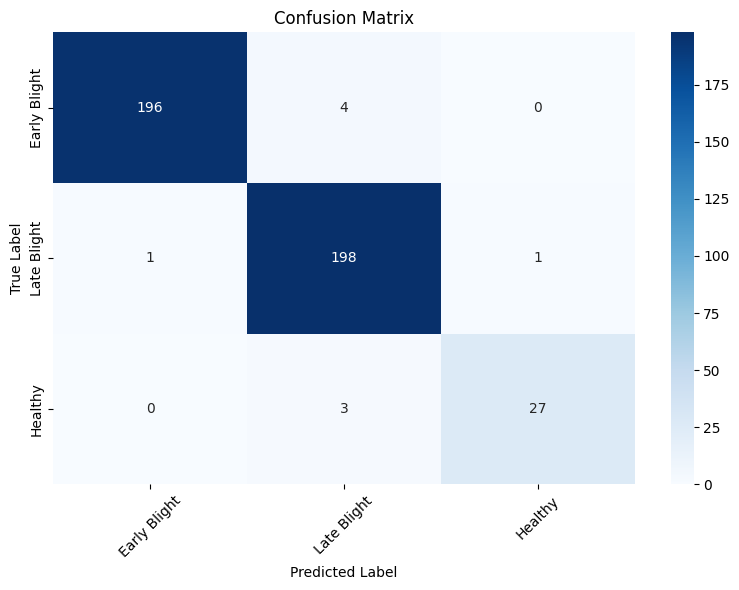

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Class names
class_names = ['Early Blight', 'Late Blight', 'Healthy']

# Get predictions
val_generator.reset()
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

# ✅ Final Accuracy
loss, accuracy = model.evaluate(val_generator)
print(f"\n✅ Final Validation Accuracy: {accuracy * 100:.2f}%")
print(f"✅ Final Validation Loss: {loss:.4f}")

# ✅ Classification Report (Precision, Recall, F1)
print("\n" + "="*55)
print("         CLASSIFICATION REPORT")
print("="*55)
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# ✅ Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()